<a href="https://colab.research.google.com/github/scientistEgong/apple-quality-ai-detector/blob/main/notebook/data-processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install datasets huggingface_hub

In [ ]:
from datasets import load_dataset

ds = load_dataset("Project-AgML/FruitVision_quality_classification", "augmented")

README.md:   0%|          | 0.00/2.08k [00:00<?, ?B/s]

augmented/train-00000-of-00010.parquet: reconstructing file:   0%|          |  0.00B /  462MB            

augmented/train-00000-of-00010.parquet: downloading bytes:           |  0.00B            

augmented/train-00001-of-00010.parquet: reconstructing file:   0%|          |  0.00B /  441MB            

augmented/train-00001-of-00010.parquet: downloading bytes:           |  0.00B            

...

augmented/train-00008-of-00010.parquet: reconstructing file:   0%|          |  0.00B /  469MB            

augmented/train-00008-of-00010.parquet: downloading bytes:           |  0.00B            

augmented/train-00009-of-00010.parquet: reconstructing file:   0%|          |  0.00B /  514MB            

augmented/train-00009-of-00010.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/73389 [00:00<?, ? examples/s]

In [ ]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'fruit'],
        num_rows: 73389
    })
})


In [ ]:
print(ds)
print(ds["train"].features)
print(ds["train"][0])

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'fruit'],
        num_rows: 73389
    })
})
{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['Formalin-mixed', 'Fresh', 'Rotten']), 'fruit': Value('string')}
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=512x512 at 0x7A2A7DF84620>, 'label': 0, 'fruit': 'Apple'}


In [ ]:
print(type(ds))
print(type(ds["train"]))

<class 'datasets.dataset_dict.DatasetDict'>
<class 'datasets.arrow_dataset.Dataset'>


In [ ]:
train = ds["train"]

apple_binary = train.filter(lambda x: x["fruit"] == "Apple" and x["label"] in [0, 1])

print(apple_binary)

Filter:   0%|          | 0/73389 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'label', 'fruit'],
    num_rows: 8084
})


In [ ]:
from collections import Counter

counter = Counter(apple_binary["label"])
print(counter)

print(ds["train"].features["label"].names)

Counter({1: 6120, 0: 1964})
['Formalin-mixed', 'Fresh', 'Rotten']


In [ ]:
from collections import Counter

counter = Counter(apple_binary["label"])
label_names = ds["train"].features["label"].names

for label_id, count in sorted(counter.items()):
    print(f"{label_names[label_id]}: {count}")

Formalin-mixed: 1964
Fresh: 6120


In [ ]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASEDSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"


print(f"TensorFlow version : {tf.__version__}")
print(f"Random seed set to : {SEED}")

TensorFlow version : 2.20.0
Random seed set to : 42


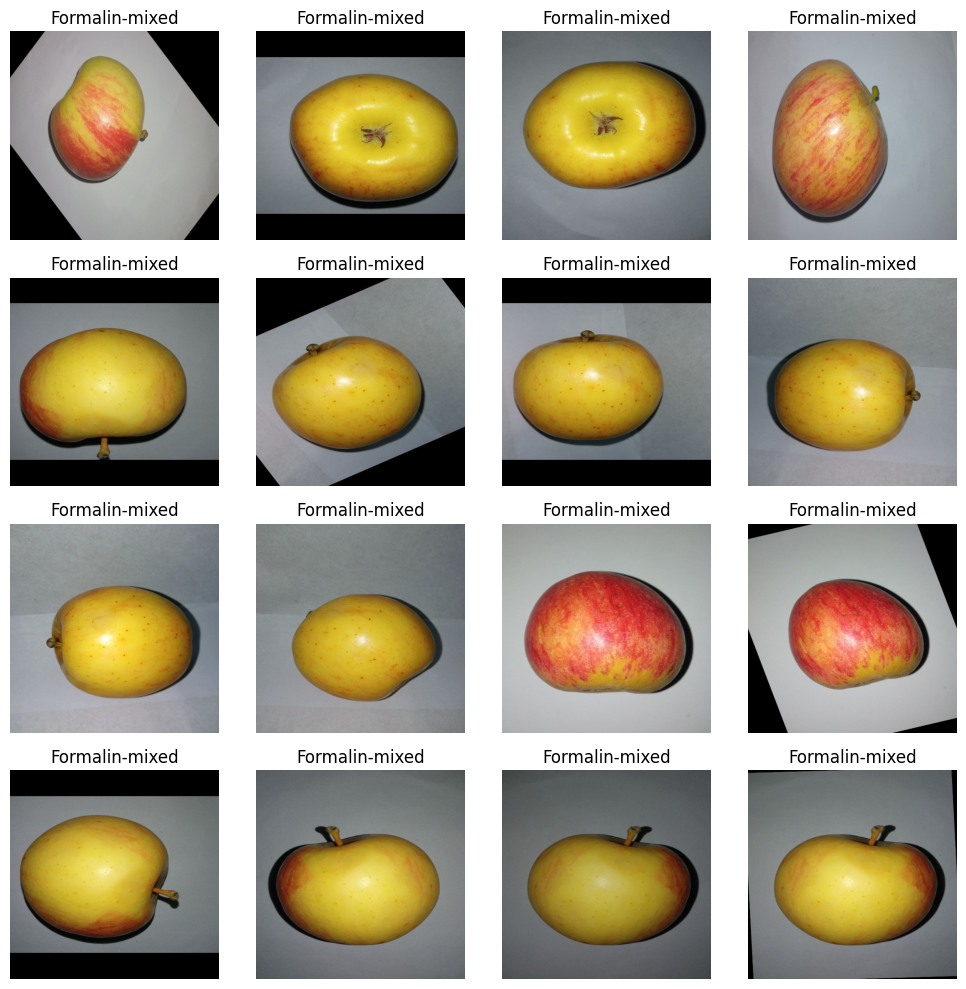

In [ ]:
label_names = ds["train"].features["label"].names

plt.figure(figsize=(10, 10))

for i in range(16):
    sample = apple_binary[i]

    plt.subplot(4, 4, i + 1)
    plt.imshow(sample["image"])
    plt.title(label_names[sample["label"]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
split = apple_binary.train_test_split(
    test_size=0.2, seed=SEED, stratify_by_column="label"
)

train_ds = split["train"]
temp_ds = split["test"]

split2 = temp_ds.train_test_split(test_size=0.5, seed=SEED, stratify_by_column="label")

val_ds = split2["train"]
test_ds = split2["test"]

print(len(train_ds), len(val_ds), len(test_ds))

6467 808 809


In [ ]:
# ===============================
# Global Hyperparameters
# ===============================

IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128

BATCH_SIZE = 64

EPOCHS = 50

LEARNING_RATE = 1e-3

NUM_CLASSES = 2

In [ ]:
import numpy as np


def preprocess(sample):
    image = sample["image"].resize((IMAGE_WIDTH, IMAGE_HEIGHT))
    image = np.array(image, dtype=np.float32) / 255.0
    label = sample["label"]
    return image, label

In [ ]:
train_images, train_labels = zip(*(preprocess(x) for x in train_ds))
val_images, val_labels = zip(*(preprocess(x) for x in val_ds))
test_images, test_labels = zip(*(preprocess(x) for x in test_ds))

train_images = np.array(train_images)
train_labels = np.array(train_labels)

val_images = np.array(val_images)
val_labels = np.array(val_labels)

test_images = np.array(test_images)
test_labels = np.array(test_labels)

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))

val_dataset = tf.data.Dataset.from_tensor_slices((val_images, val_labels))

test_dataset = tf.data.Dataset.from_tensor_slices((test_images, test_labels))

In [ ]:
train_dataset = train_dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential(
    [
        layers.Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [ ]:
history = model.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS)

Epoch 1/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.7599 - loss: 0.5066 - val_accuracy: 0.7661 - val_loss: 0.4440
Epoch 2/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.7929 - loss: 0.4224 - val_accuracy: 0.8465 - val_loss: 0.3760
Epoch 3/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.8435 - loss: 0.3691 - val_accuracy: 0.8465 - val_loss: 0.3766
Epoch 4/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.8746 - loss: 0.3211 - val_accuracy: 0.8899 - val_loss: 0.2876
Epoch 5/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.8992 - loss: 0.2601 - val_accuracy: 0.9072 - val_loss: 0.2470
Epoch 6/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9061 - loss: 0.2413 - val_accuracy: 0.9220 - val_loss: 0.2172
Epoch 7/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9188 - loss: 0.2049 - val_accuracy: 0.9517 - val_loss: 0.1621
Epoch 8/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9283 - loss: 0.1817 - val_acc

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9765 - loss: 0.1851
Test Loss: 0.18513131141662598
Test Accuracy: 0.9765142202377319


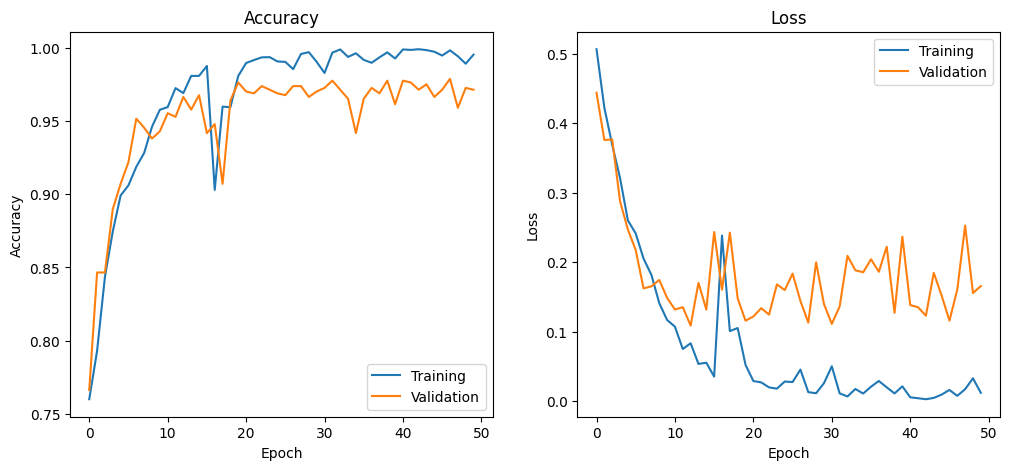

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


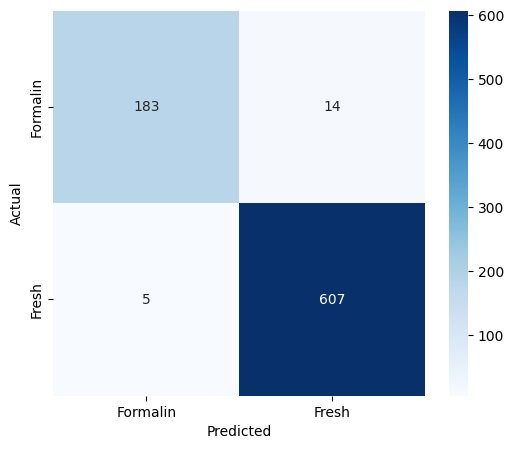

In [ ]:
y_true = test_labels

y_pred = model.predict(test_dataset)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Formalin", "Fresh"],
    yticklabels=["Formalin", "Fresh"],
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print(classification_report(y_true, y_pred, target_names=["Formalin-mixed", "Fresh"]))

                precision    recall  f1-score   support

Formalin-mixed       0.97      0.93      0.95       197
         Fresh       0.98      0.99      0.98       612

      accuracy                           0.98       809
     macro avg       0.98      0.96      0.97       809
  weighted avg       0.98      0.98      0.98       809



In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_apple_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)

early_stop = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop],
)

Epoch 1/50
101/102 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9956 - loss: 0.0115
Epoch 1: val_accuracy improved from None to 0.96287, saving model to best_apple_cnn.keras

Epoch 1: finished saving model to best_apple_cnn.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9951 - loss: 0.0128 - val_accuracy: 0.9629 - val_loss: 0.2448
Epoch 2/50
101/102 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9955 - loss: 0.0103
Epoch 2: val_accuracy improved from 0.96287 to 0.96658, saving model to best_apple_cnn.keras

Epoch 2: finished saving model to best_apple_cnn.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9960 - loss: 0.0093 - val_accuracy: 0.9666 - val_loss: 0.1890
Epoch 3/50
101/102 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9988 - loss: 0.0048
Epoch 3: val_accuracy improved from 0.96658 to 0.97525, saving model to best_apple_cnn.keras

Epoch 3: finished saving model to best_apple_cnn.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.998

In [ ]:
os.makedirs("best_models", exist_ok=True)

model.save("best_models/apple_formalin_classifier.keras")